# Nhập môn học máy - Kiểm tra cuối kỳ

- Họ và tên: Nguyễn Phúc Khang
- MSSV: 22127180

# Thư viện cần thiết

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold

# Tiền xử lý dữ liệu

#### Đọc file `train.csv` và `test.csv`

In [2]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

#### Quan sát cột dữ liệu

- Quan sát các dòng đầu của tập dữ liệu để có cái nhìn tổng quan hơn

In [3]:
train_data.head(10)

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1,842,0,2.2,0,1,0,7,0.6,188,...,20,756,2549,9,7,19,0,0,1,1
1,2,1021,1,0.5,1,0,1,53,0.7,136,...,905,1988,2631,17,3,7,1,1,0,2
2,3,563,1,0.5,1,2,1,41,0.9,145,...,1263,1716,2603,11,2,9,1,1,0,2
3,4,615,1,2.5,0,0,0,10,0.8,131,...,1216,1786,2769,16,8,11,1,0,0,2
4,5,1821,1,1.2,0,13,1,44,0.6,141,...,1208,1212,1411,8,2,15,1,1,0,1
5,6,1859,0,0.5,1,3,0,22,0.7,164,...,1004,1654,1067,17,1,10,1,0,0,1
6,7,1821,0,1.7,0,4,1,10,0.8,139,...,381,1018,3220,13,8,18,1,0,1,3
7,8,1954,0,0.5,1,0,0,24,0.8,187,...,512,1149,700,16,3,5,1,1,1,0
8,9,1445,1,0.5,0,0,0,53,0.7,174,...,386,836,1099,17,1,20,1,0,0,0
9,10,509,1,0.6,1,2,1,9,0.1,93,...,1137,1224,513,19,10,12,1,0,0,0


- Tiếp theo, ta sẽ xem xét các cột có giá trị thiếu trong tập dữ liệu đào tạo và tập dữ liệu kiểm tra.

In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2000 non-null   int64  
 1   battery_power  2000 non-null   int64  
 2   blue           2000 non-null   int64  
 3   clock_speed    2000 non-null   float64
 4   dual_sim       2000 non-null   int64  
 5   fc             2000 non-null   int64  
 6   four_g         2000 non-null   int64  
 7   int_memory     2000 non-null   int64  
 8   m_dep          2000 non-null   float64
 9   mobile_wt      2000 non-null   int64  
 10  n_cores        2000 non-null   int64  
 11  pc             2000 non-null   int64  
 12  px_height      2000 non-null   int64  
 13  px_width       2000 non-null   int64  
 14  ram            2000 non-null   int64  
 15  sc_h           2000 non-null   int64  
 16  sc_w           2000 non-null   int64  
 17  talk_time      2000 non-null   int64  
 18  three_g 

##### Kích thước dữ liệu
- Dataset có 2000 hàng và 22 cột.
- Cột `price_range` là biến mục tiêu (target variable), các cột còn lại là đặc trưng.

##### Dữ liệu không có giá trị bị thiếu
- Không có giá trị null trong bất kỳ cột nào.

##### Loại dữ liệu
- Hầu hết các cột có kiểu dữ liệu `int64`, ngoại trừ hai cột (`clock_speed` và `m_dep`) có kiểu `float64`.

##### Các cột đặc trưng
- **Cột `id`**: Không liên quan đến dự đoán, ta sẽ cần loại bỏ cột dữ liệu này trước khi huấn luyện.
- Các cột còn lại không cần xử lý thêm

##### Cột mục tiêu (`price_range`)
- Đây là một bài toán phân loại với 4 lớp (`0`, `1`, `2`, `3`).
- Các giá trị đã được mã hóa, không cần xử lý thêm.

In [5]:
train_data = train_data.drop(['id'], axis=1)
test_data = test_data.drop(['id'], axis=1)

#### Chọn đặc trưng để huấn luyện mô hình
- Ta sẽ vẽ biểu đồ để xem xét mối tương quan giữa các đặc trưng với đặc trưng mục tiêu là `price_range`

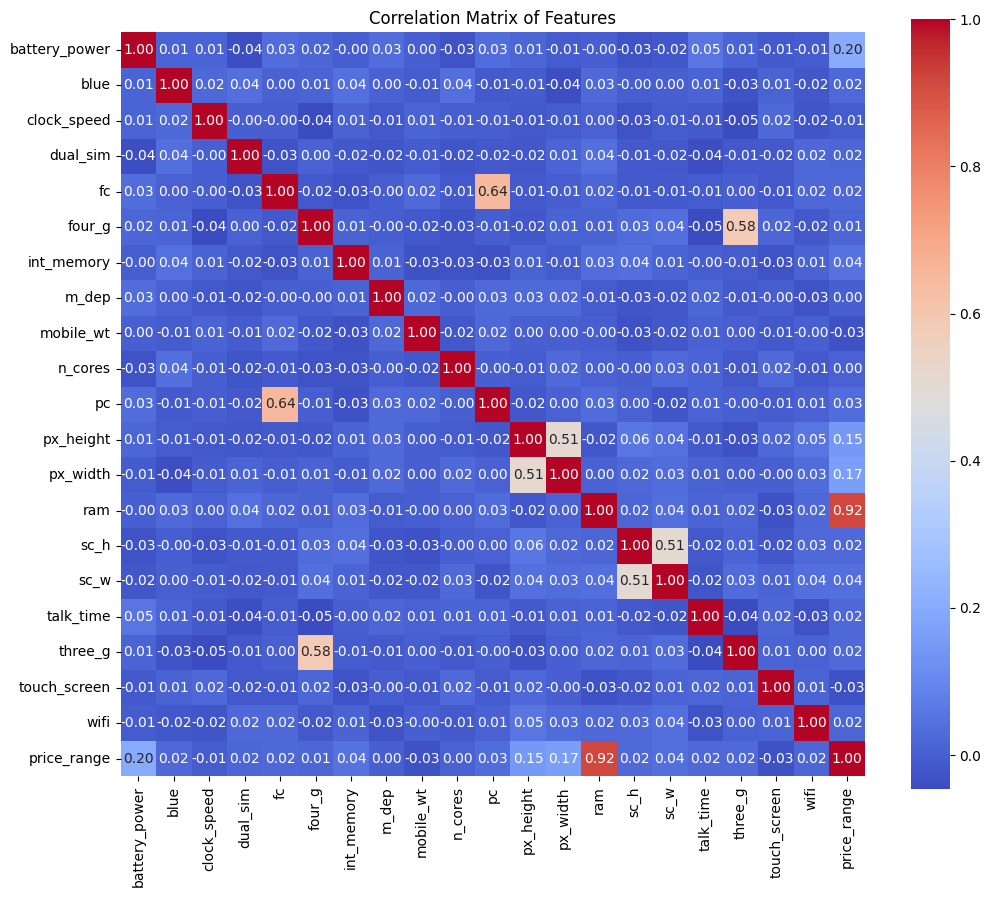

In [6]:
corr_matrix = train_data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Matrix of Features")
plt.show()

- Sau khi xem xét ma trận tương quan, ta sẽ chọn ra các đặc trưng có mức tương quan lớn hơn 0 với đặc trưng target `price_range` để xây dựng mô hình.

In [7]:
corr_matrix = train_data.corr()
corr_target = corr_matrix['price_range'].sort_values(ascending=False)
corr_target_high = corr_target[corr_target > 0][1:]
features = corr_target_high.index.tolist()

print("Các đặc trưng có tương quan lớn hơn 0 với price_range:")
corr_target_high


Các đặc trưng có tương quan lớn hơn 0 với price_range:


ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
Name: price_range, dtype: float64

- Tạo tập dữ liệu huấn luyện và tập dữ liệu kiểm thử


In [8]:
X_train = train_data[features]
y_train = train_data['price_range']

X_test = test_data[features]
y_test = test_data['price_range']

### Chuẩn hóa dữ liệu với MinMaxScaler
- Để mô hình học máy huấn luyện hiệu quả hơn, đặc biệt là khi làm việc với các thuật toán như Neural Network, việc chuẩn hóa dữ liệu là bước quan trọng. 

- Chuẩn hóa đảm bảo rằng các đặc trưng nằm trong một phạm vi giá trị cụ thể (thường là [0, 1]). Việc chuẩn hóa sẽ giúp:

    - **Tăng tốc độ hội tụ của thuật toán**: Do các đặc trưng có phạm vi khác nhau, các thuật toán thường gặp khó khăn trong việc tìm kiếm giá trị tối ưu, làm chậm quá trình hội tụ.

    - **Tránh ưu tiên sai cho các đặc trưng có phạm vi giá trị lớn**: Các đặc trưng với giá trị lớn có thể lấn át các đặc trưng nhỏ hơn khi tính toán khoảng cách hoặc trọng số trong các mô hình

    - **Cải thiện hiệu suất mô hình**: Một số mô hình nhạy cảm với sự khác biệt về phạm vi giá trị, ví dụ như Neural Network hay Gradient Descent.


In [9]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(test_data[features])

# Lựa chọn mô hình: KNN và Neural Network

### Mô hình K-Nearest Neighbors (KNN)

**Lý do chọn KNN:**

- KNN là một thuật toán đơn giản, trực quan và dễ hiểu, dựa trên khoảng cách giữa các điểm dữ liệu trong không gian đặc trưng. 

- Với tập dữ liệu có kích thước vừa phải (2000 dòng trong tập huấn luyện), KNN hoạt động tốt mà không cần nhiều tài nguyên tính toán.

- Bài toán dự đoán giá điện thoại là bài toán phân loại đa lớp (4 lớp). KNN có thể được áp dụng dễ dàng bằng cách chọn nhãn phổ biến nhất trong `k` hàng xóm gần nhất.

In [10]:
class KNN:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def load_model_weights(self, filepath):
        print("KNN is a non-parametric model; it does not use weights.")

    def train(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train.reset_index(drop=True)

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = self.y_train[k_indices]
        unique, counts = np.unique(k_nearest_labels, return_counts=True)
        return unique[np.argmax(counts)]

    def evaluate(self, X_test, y_test):
        y_pred = self.predict(X_test)
        accuracy = np.mean(y_pred == y_test)
        loss = 1 - accuracy 
        return accuracy, loss

kf = KFold(n_splits=5, shuffle=True, random_state=42)
knn_model = KNN()

knn_accuracies = []
knn_losses = []

print("KNN - KFold Cross Validation Results:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled), 1):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    knn_model.train(X_train_fold, y_train_fold)
    fold_accuracy, fold_loss = knn_model.evaluate(X_val_fold, y_val_fold)
    knn_accuracies.append(fold_accuracy)
    knn_losses.append(fold_loss)
    
    print(f"Fold {fold}: Accuracy = {fold_accuracy:.4f}, Loss = {fold_loss:.4f}")

avg_knn_accuracy = np.mean(knn_accuracies)
avg_knn_loss = np.mean(knn_losses)

knn_model.train(X_train_scaled, y_train)
train_accuracy, train_loss = knn_model.evaluate(X_train_scaled, y_train)
test_accuracy, test_loss = knn_model.evaluate(X_test_scaled, y_test)

print("\nKNN - Summary Results:")
print(f"Avg KFold Accuracy: {avg_knn_accuracy:.4f}, Avg KFold Loss: {avg_knn_loss:.4f}")
print(f"Train Set Accuracy: {train_accuracy:.4f}, Train Set Loss: {train_loss:.4f}")
print(f"Test Set Accuracy: {test_accuracy:.4f}, Test Set Loss: {test_loss:.4f}")

KNN - KFold Cross Validation Results:
Fold 1: Accuracy = 0.4500, Loss = 0.5500
Fold 2: Accuracy = 0.4350, Loss = 0.5650
Fold 3: Accuracy = 0.4975, Loss = 0.5025
Fold 4: Accuracy = 0.4125, Loss = 0.5875
Fold 5: Accuracy = 0.4050, Loss = 0.5950

KNN - Summary Results:
Avg KFold Accuracy: 0.4400, Avg KFold Loss: 0.5600
Train Set Accuracy: 0.6740, Train Set Loss: 0.3260
Test Set Accuracy: 0.2510, Test Set Loss: 0.7490


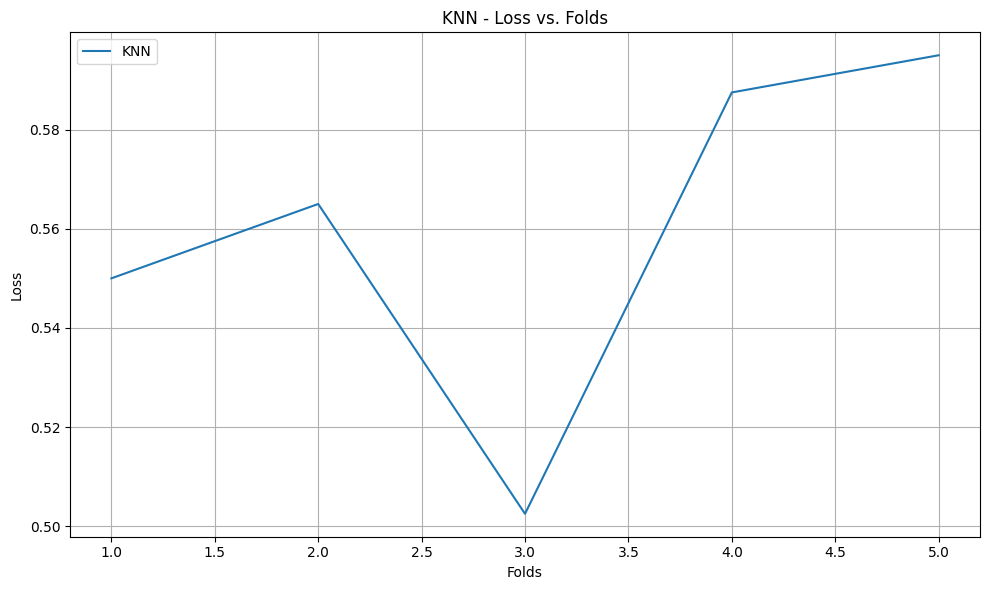

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=np.linspace(1, 5, num=5, dtype=int), y=knn_losses, label="KNN")
plt.title("KNN - Loss vs. Folds")
plt.xlabel("Folds")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Mô hình Neural Network (NN)

**Lý do chọn**
- Neural Network có thể mô hình hóa các mối quan hệ phi tuyến phức tạp trong dữ liệu. Đây là lợi thế so với các mô hình tuyến tính hoặc dựa vào khoảng cách như KNN.
- Dữ liệu điện thoại bao gồm 21 đặc trưng đầu vào. Neural Network có thể tự động học được các kết hợp phi tuyến giữa các đặc trưng này để đưa ra dự đoán chính xác.
- Neural Network cho phép tùy chỉnh cấu trúc, số lớp, số lượng nơ-ron để phù hợp với bài toán. Trong bài toán này, mô hình được thiết kế với hai lớp ẩn để tận dụng tốt các đặc trưng.


In [12]:
class NeuralNetwork:
    def __init__(self, epochs=1000, learning_rate=0.001):
        self.epochs = epochs
        self.learning_rate = learning_rate

        self.input_size = X_train.shape[1]
        self.hidden_size_1 = self.input_size * 2
        self.hidden_size_2 = self.input_size
        self.output_size = 4  

        np.random.seed(42)
        self.W1 = np.random.randn(self.input_size, self.hidden_size_1) * 0.1
        self.b1 = np.zeros((1, self.hidden_size_1))
        self.W2 = np.random.randn(self.hidden_size_1, self.hidden_size_2) * 0.1
        self.b2 = np.zeros((1, self.hidden_size_2))
        self.W3 = np.random.randn(self.hidden_size_2, self.output_size) * 0.1
        self.b3 = np.zeros((1, self.output_size))

        self.losses = {"train": []}
        self.accuracies = {"train": []}

    def load_model_weights(self, filepath):
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        data = {}
        for line in lines:
            line = line.strip()
            if line.startswith('"') and ":" in line:
                key, value = line.split(":", 1)
                key = key.strip('"')
                value = eval(value.rstrip(","))
                data[key] = value
        
        self.W1 = np.array(data["W1"])
        self.b1 = np.array(data["b1"])
        self.W2 = np.array(data["W2"])
        self.b2 = np.array(data["b2"])
        self.W3 = np.array(data["W3"])
        self.b3 = np.array(data["b3"])


    def save_model_weights(self, filepath):
        data = {
            "W1": self.W1.tolist(),
            "b1": self.b1.tolist(),
            "W2": self.W2.tolist(),
            "b2": self.b2.tolist(),
            "W3": self.W3.tolist(),
            "b3": self.b3.tolist(),
        }
        
        with open(filepath, 'w') as f:
            f.write("{\n")
            for key, value in data.items():
                f.write(f'  "{key}": {value},\n')
            f.write("}\n")
        
    def one_hot_encode(self, y):
        return np.eye(np.max(y) + 1)[y]

    def relu(self, x):
        return np.maximum(0, x)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward_pass(self, X):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self.relu(Z1)
        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self.relu(Z2)
        Z3 = np.dot(A2, self.W3) + self.b3
        A3 = self.softmax(Z3)
        return A1, A2, A3

    def compute_loss(self, A3, Y):
        m = Y.shape[0]
        log_likelihood = -np.log(A3[range(m), np.argmax(Y, axis=1)])
        loss = np.sum(log_likelihood) / m
        return loss

    def backprop(self, X, Y, A1, A2, A3):
        m = X.shape[0]
        dZ3 = A3 - Y
        dW3 = np.dot(A2.T, dZ3) / m
        db3 = np.sum(dZ3, axis=0, keepdims=True) / m

        dA2 = np.dot(dZ3, self.W3.T)
        dZ2 = dA2 * (A2 > 0)
        dW2 = np.dot(A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (A1 > 0)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        return dW1, db1, dW2, db2, dW3, db3

    def update_weights(self, dW1, db1, dW2, db2, dW3, db3):
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W3 -= self.learning_rate * dW3
        self.b3 -= self.learning_rate * db3

    def train(self, X_train, y_train):
        y_train_onehot = self.one_hot_encode(y_train)
        for _ in range(self.epochs):
            A1, A2, A3 = self.forward_pass(X_train)
            train_loss = self.compute_loss(A3, y_train_onehot)
            dW1, db1, dW2, db2, dW3, db3 = self.backprop(X_train, y_train_onehot, A1, A2, A3)
            self.update_weights(dW1, db1, dW2, db2, dW3, db3)

            self.losses["train"].append(train_loss)
            train_accuracy = self.evaluate(X_train, y_train)
            self.accuracies["train"].append(train_accuracy)

    def evaluate(self, X_test, y_test):
        _, _, A3 = self.forward_pass(X_test)
        y_pred = np.argmax(A3, axis=1)
        accuracy = np.mean(y_pred == y_test)
        return accuracy

    def loss(self, X, y):
        _, _, A3 = self.forward_pass(X)
        y_onehot = self.one_hot_encode(y)
        loss = self.compute_loss(A3, y_onehot)
        return loss


kf = KFold(n_splits=5, shuffle=True, random_state=42)
nn = NeuralNetwork(epochs=1000, learning_rate=0.001)

nn_accuracies = []
nn_losses = []

print("Neural Network - KFold Cross Validation Results:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled), 1):
    X_train_fold, X_val_fold = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
    
    nn.train(X_train_fold, y_train_fold)
    
    fold_accuracy = nn.evaluate(X_val_fold, y_val_fold)
    fold_loss = nn.loss(X_val_fold, y_val_fold) 
    nn_accuracies.append(fold_accuracy)
    nn_losses.append(fold_loss)
    
    print(f"Fold {fold}: Accuracy = {fold_accuracy:.4f}, Loss = {fold_loss:.4f}")

nn.train(X_train_scaled, y_train)
nn.save_model_weights("weights.json")
avg_nn_accuracy = np.mean(nn_accuracies)
avg_nn_loss = np.mean(nn_losses)

train_accuracy = nn.evaluate(X_train_scaled, y_train)
train_loss = nn.loss(X_train_scaled, y_train)
test_accuracy = nn.evaluate(X_test_scaled, y_test)
test_loss = nn.loss(X_test_scaled, y_test)

print("\nNeural Network - Summary Results:")
print(f"Avg KFold Accuracy: {avg_nn_accuracy:.4f}, Avg KFold Loss: {avg_nn_loss:.4f}")
print(f"Train Set Accuracy: {train_accuracy:.4f}, Train Set Loss: {train_loss:.4f}")
print(f"Test Set Accuracy: {test_accuracy:.4f}, Test Set Loss: {test_loss:.4f}")

Neural Network - KFold Cross Validation Results:
Fold 1: Accuracy = 0.2250, Loss = 1.3878
Fold 2: Accuracy = 0.2625, Loss = 1.3847
Fold 3: Accuracy = 0.3375, Loss = 1.3819
Fold 4: Accuracy = 0.2900, Loss = 1.3820
Fold 5: Accuracy = 0.3225, Loss = 1.3825

Neural Network - Summary Results:
Avg KFold Accuracy: 0.2875, Avg KFold Loss: 1.3838
Train Set Accuracy: 0.3710, Train Set Loss: 1.3805
Test Set Accuracy: 0.3220, Test Set Loss: 1.3819


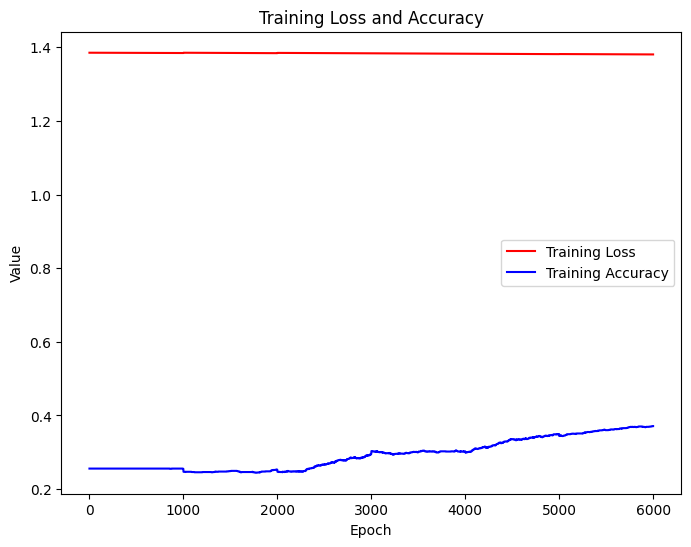

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(nn.losses["train"], label="Training Loss", color="r")
plt.plot(nn.accuracies["train"], label="Training Accuracy", color="b")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss and Accuracy")
plt.legend()
plt.show()